In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
print(os.getcwd())

e:\student-performance-pridictor\notebooks


In [4]:
df = pd.read_csv('../data/student-mat.csv')

In [5]:
df.head()

,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Parrent_status',
       'Mother_edu', 'Father_edu', 'Mother_job', 'Father_job',
       'reason_to_chose_school', 'guardian', 'traveltime', 'weekly_studytime',
       'failures', 'extra_edu_supp', 'family_edu_supp', 'extra_paid_class',
       'extra_curr_activities', 'nursery', 'Interested_in_higher_edu',
       'internet_access', 'romantic_relationship', 'Family_quality_reln',
       'freetime_after_school', 'goout_with_friends', 'workday_alcohol_consum',
       'weekend_alcohol_consum', 'health_status', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

In [10]:
df['weekly_studytime'].max()

4

In [11]:
df['weekly_studytime'].min()

1

In [12]:
df['absences'].min()

0

In [13]:
df['absences'].max()

75

In [6]:
df.shape

(395, 33)

In [7]:
#missing values
df.isnull().sum().sum()

0

In [8]:
#finding categorical columns
cat_cols = df.select_dtypes(include=['object','category']).columns
cat_cols

Index(['school', 'sex', 'address', 'famsize', 'Parrent_status', 'Mother_job',
       'Father_job', 'reason_to_chose_school', 'guardian', 'extra_edu_supp',
       'family_edu_supp', 'extra_paid_class', 'extra_curr_activities',
       'nursery', 'Interested_in_higher_edu', 'internet_access',
       'romantic_relationship'],
      dtype='object')

In [9]:
#unique value in each categorical columns
for col in cat_cols:
    print(f'\n{col} ({df[col].nunique()} unique values):')
    print(f'  {df[col].unique().tolist()}')


school (2 unique values):
  ['GP', 'MS']

sex (2 unique values):
  ['F', 'M']

address (2 unique values):
  ['U', 'R']

famsize (2 unique values):
  ['GT3', 'LE3']

Parrent_status (2 unique values):
  ['A', 'T']

Mother_job (5 unique values):
  ['at_home', 'health', 'other', 'services', 'teacher']

Father_job (5 unique values):
  ['teacher', 'other', 'services', 'health', 'at_home']

reason_to_chose_school (4 unique values):
  ['course', 'other', 'home', 'reputation']

guardian (3 unique values):
  ['mother', 'father', 'other']

extra_edu_supp (2 unique values):
  ['yes', 'no']

family_edu_supp (2 unique values):
  ['no', 'yes']

extra_paid_class (2 unique values):
  ['no', 'yes']

extra_curr_activities (2 unique values):
  ['no', 'yes']

nursery (2 unique values):
  ['yes', 'no']

Interested_in_higher_edu (2 unique values):
  ['yes', 'no']

internet_access (2 unique values):
  ['no', 'yes']

romantic_relationship (2 unique values):
  ['no', 'yes']


In [10]:
df.describe()

,age,Mother_edu,Father_edu,traveltime,weekly_studytime,failures,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   school                    395 non-null    object
 1   sex                       395 non-null    object
 2   age                       395 non-null    int64 
 3   address                   395 non-null    object
 4   famsize                   395 non-null    object
 5   Parrent_status            395 non-null    object
 6   Mother_edu                395 non-null    int64 
 7   Father_edu                395 non-null    int64 
 8   Mother_job                395 non-null    object
 9   Father_job                395 non-null    object
 10  reason_to_chose_school    395 non-null    object
 11  guardian                  395 non-null    object
 12  traveltime                395 non-null    int64 
 13  weekly_studytime          395 non-null    int64 
 14  failures                  

In [12]:
#duplicates
df.duplicated().sum()

0

In [13]:
#missing values
df.isnull().sum().sum()

0

In [15]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Parrent_status',
       'Mother_edu', 'Father_edu', 'Mother_job', 'Father_job',
       'reason_to_chose_school', 'guardian', 'traveltime', 'weekly_studytime',
       'failures', 'extra_edu_supp', 'family_edu_supp', 'extra_paid_class',
       'extra_curr_activities', 'nursery', 'Interested_in_higher_edu',
       'internet_access', 'romantic_relationship', 'Family_quality_reln',
       'freetime_after_school', 'goout_with_friends', 'workday_alcohol_consum',
       'weekend_alcohol_consum', 'health_status', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

In [21]:
new_df=df[['weekly_studytime','G1','G2','G3']]


In [22]:
new_df

,weekly_studytime,G1,G2,G3
0,2,5,6,6
1,2,5,5,6
2,2,7,8,10
3,3,15,14,15
4,2,6,10,10
...,...,...,...,...
390,2,9,9,9
391,1,14,16,16
392,1,10,8,7
393,1,11,12,10


In [25]:
# Calculate correlations with G3
correlations = new_df.corr()['G3'].sort_values(ascending=False)
correlations

G3                  1.000000
G2                  0.904868
G1                  0.801468
weekly_studytime    0.097820
Name: G3, dtype: float64

In [34]:

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

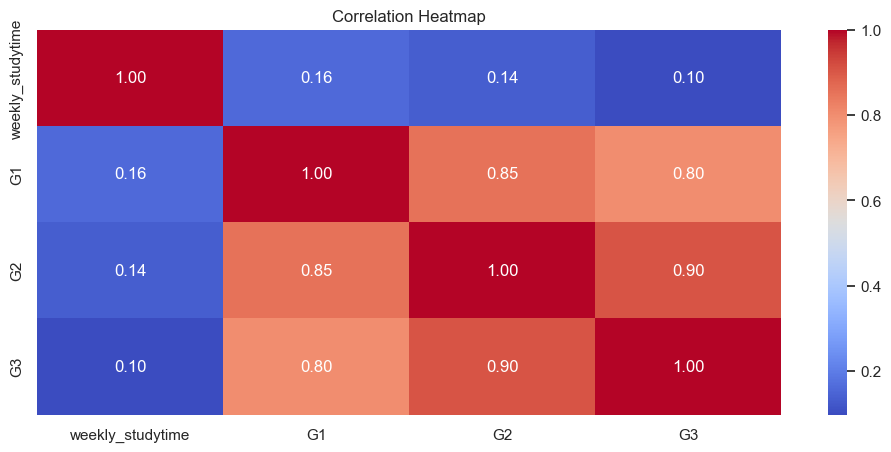

In [35]:
sns.heatmap(new_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score

In [37]:
from sklearn.model_selection import train_test_split
# Separate independent features X and target y
X = new_df.drop(columns=['G3'])
y = new_df['G3']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Linear Regression Results:')
print(f'  MAE: {mean_absolute_error(y_test, y_pred_lr):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}')
print(f'  R2 Score: {r2_score(y_test, y_pred_lr):.4f}')

Linear Regression Results:
  MAE: 1.2656
  RMSE: 2.0412
  R2 Score: 0.7968


In [41]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('Decision Tree Results:')
print(f'  MAE: {mean_absolute_error(y_test, y_pred_dt):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.4f}')
print(f'  R2 Score: {r2_score(y_test, y_pred_dt):.4f}')


Decision Tree Results:
  MAE: 1.0675
  RMSE: 1.6476
  R2 Score: 0.8676


In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest Results:')
print(f'  MAE: {mean_absolute_error(y_test, y_pred_rf):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}')
print(f'  R2 Score: {r2_score(y_test, y_pred_rf):.4f}')

Random Forest Results:
  MAE: 1.2509
  RMSE: 1.8751
  R2 Score: 0.8285


In [43]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('Gradient Boosting Results:')
print(f'  MAE: {mean_absolute_error(y_test, y_pred_gb):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.4f}')
print(f'  R2 Score: {r2_score(y_test, y_pred_gb):.4f}')

Gradient Boosting Results:
  MAE: 1.3248
  RMSE: 2.0995
  R2 Score: 0.7850


In [44]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_dt), 
            mean_absolute_error(y_test, y_pred_rf), mean_absolute_error(y_test, y_pred_gb)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)), np.sqrt(mean_squared_error(y_test, y_pred_dt)), 
             np.sqrt(mean_squared_error(y_test, y_pred_rf)), np.sqrt(mean_squared_error(y_test, y_pred_gb))],
    'R2 Score': [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_dt), 
                 r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_gb)]
})

print('Model Performance Comparison:')
results.sort_values(by='R2 Score', ascending=False)

Model Performance Comparison:


,Model,MAE,RMSE,R2 Score
1,Decision Tree,1.067495,1.647568,0.867619
2,Random Forest,1.250910,1.875143,0.828522
0,Linear Regression,1.265578,2.041216,0.796803
3,Gradient Boosting,1.324758,2.099538,0.785026
